<a href="https://colab.research.google.com/github/miguelvelezsk/ML-Softserver-Notebooks/blob/main/FIFA_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Football Player Position Classifier**

**BY: Miguelangel Vélez Aguirre**

### **Mount drive & Dataset**

In [1]:
from google.colab import drive
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
NOTEBOOK_DIR = Path('/content/drive/My Drive/Colab Notebooks/datasets')
os.chdir(NOTEBOOK_DIR)
print("Current dir:", os.getcwd())

print('Directory elements:')
print(os.listdir(NOTEBOOK_DIR))

Current dir: /content/drive/My Drive/Colab Notebooks/datasets
Directory elements:
['players_20.csv']


In [4]:
df = pd.read_csv(NOTEBOOK_DIR/'players_20.csv')
print(df.columns.tolist())
df.head()

['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


### **Inspect our target column**

In [5]:
print(df['player_positions'].unique()[:30])
print()
print(df['player_positions'].value_counts().head(15))

['RW, CF, ST' 'ST, LW' 'LW, CAM' 'GK' 'LW, CF' 'CAM, CM' 'CB' 'CM'
 'RW, ST' 'ST, RW' 'ST' 'CDM, CM' 'CF, ST, LW' 'CAM, RW' 'CM, CDM'
 'RW, LW' 'CAM, LM, ST' 'ST, LM' 'LW, LM' 'CB, LB' 'RW, CAM, CM' 'CDM'
 'CF, LM' 'CF, ST' 'LB' 'CM, CAM, CDM' 'CF, LW, ST' 'LW' 'CB, CDM'
 'RB, CM, CDM']

player_positions
CB         2322
GK         2036
ST         1809
CM          786
CDM, CM     731
CM, CDM     682
LB          669
RB          587
CDM         363
CAM         291
CB, RB      255
LM          247
RM          227
CAM, CM     222
RM, LM      221
Name: count, dtype: int64


### **Extract the main position in player_position**

In [6]:
df['main_position'] = df['player_positions'].str.split(',').str[0].str.strip()

print(df['main_position'].unique())
print()
print(df['main_position'].value_counts())

['RW' 'ST' 'LW' 'GK' 'CAM' 'CB' 'CM' 'CDM' 'CF' 'LB' 'RB' 'RM' 'LM' 'LWB'
 'RWB']

main_position
CB     3162
ST     2582
CM     2193
GK     2036
CDM    1424
RB     1314
LB     1303
CAM    1146
RM     1050
LM     1049
LW      378
RW      369
CF      113
LWB      90
RWB      69
Name: count, dtype: int64


### **Group player_position in 4 macro-categories (GK, DEF, MID, FWD)**

In [7]:
position_groups = {
    'GK': 'GK',
    'CB': 'DEF', 'LB': 'DEF', 'RB': 'DEF', 'LWB': 'DEF', 'RWB': 'DEF',
    'CDM': 'MID', 'CM': 'MID', 'CAM': 'MID', 'LM': 'MID', 'RM': 'MID',
    'LW': 'FWD', 'RW': 'FWD', 'ST': 'FWD', 'CF': 'FWD'
}


In [12]:
df['position'] = df['main_position'].map(position_groups)

print(df['position'].value_counts())
print()
print("NaN values:", df['position'].isnull().sum())

position
MID    6862
DEF    5938
FWD    3442
GK     2036
Name: count, dtype: int64

NaN values: 0


### **EDA features**

In [13]:
features = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

In [14]:
print(df[features].isnull().sum())
print()
print("Rows number:", len(df))

pace         2036
shooting     2036
passing      2036
dribbling    2036
defending    2036
physic       2036
dtype: int64

Rows number: 18278


As we can see, we have 2036 rows with null values in our features, the same number of goalkeepers. Since, we need to delete gk positions from our model dataset

In [15]:
df_clean = df.dropna(subset=features).copy()

In [16]:
print("Rows before gk drop:", len(df))
print("Rows after gk drop:", len(df_clean))
print()
print(df_clean['position'].value_counts())

Rows before gk drop: 18278
Rows after gk drop: 16242

position
MID    6862
DEF    5938
FWD    3442
Name: count, dtype: int64


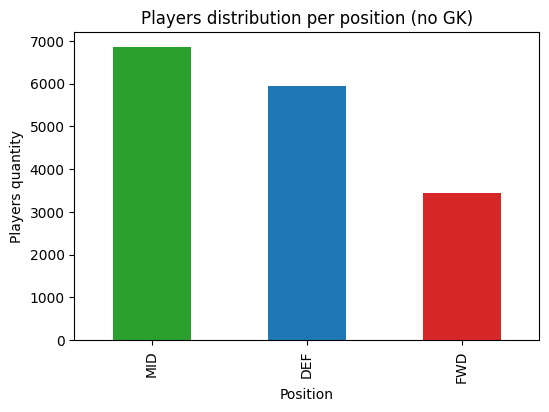

In [34]:
plt.figure(figsize=(6,4))
df_clean['position'].value_counts().plot(kind='bar', color=['#2ca02c','#1f77b4','#d62728'])
plt.title('Players distribution per position (no GK)')
plt.ylabel('Players quantity')
plt.xlabel('Position')
plt.show()

In [17]:
df_clean.groupby('position')[features].mean().round(1)

,pace,shooting,passing,dribbling,defending,physic
position,,,,,,
DEF,64.6,40.1,52.4,55.9,64.4,68.6
FWD,71.2,64.5,54.9,65.8,31.5,63.2
MID,68.7,56.8,62.5,66.6,50.5,62.5


### **Train / Test split**

In [18]:
X = df_clean[features]
y = df_clean['position']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16242, 6)
y shape: (16242,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
print("Train:", X_train.shape, " Test:", X_test.shape)
print()
print("Class ratio in train:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Class ration in test:")
print(y_test.value_counts(normalize=True).round(3))

Train: (12993, 6)  Test: (3249, 6)

Class ratio in train:
position
MID    0.422
DEF    0.366
FWD    0.212
Name: proportion, dtype: float64

Class ration in test:
position
MID    0.423
DEF    0.366
FWD    0.212
Name: proportion, dtype: float64


In [21]:
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

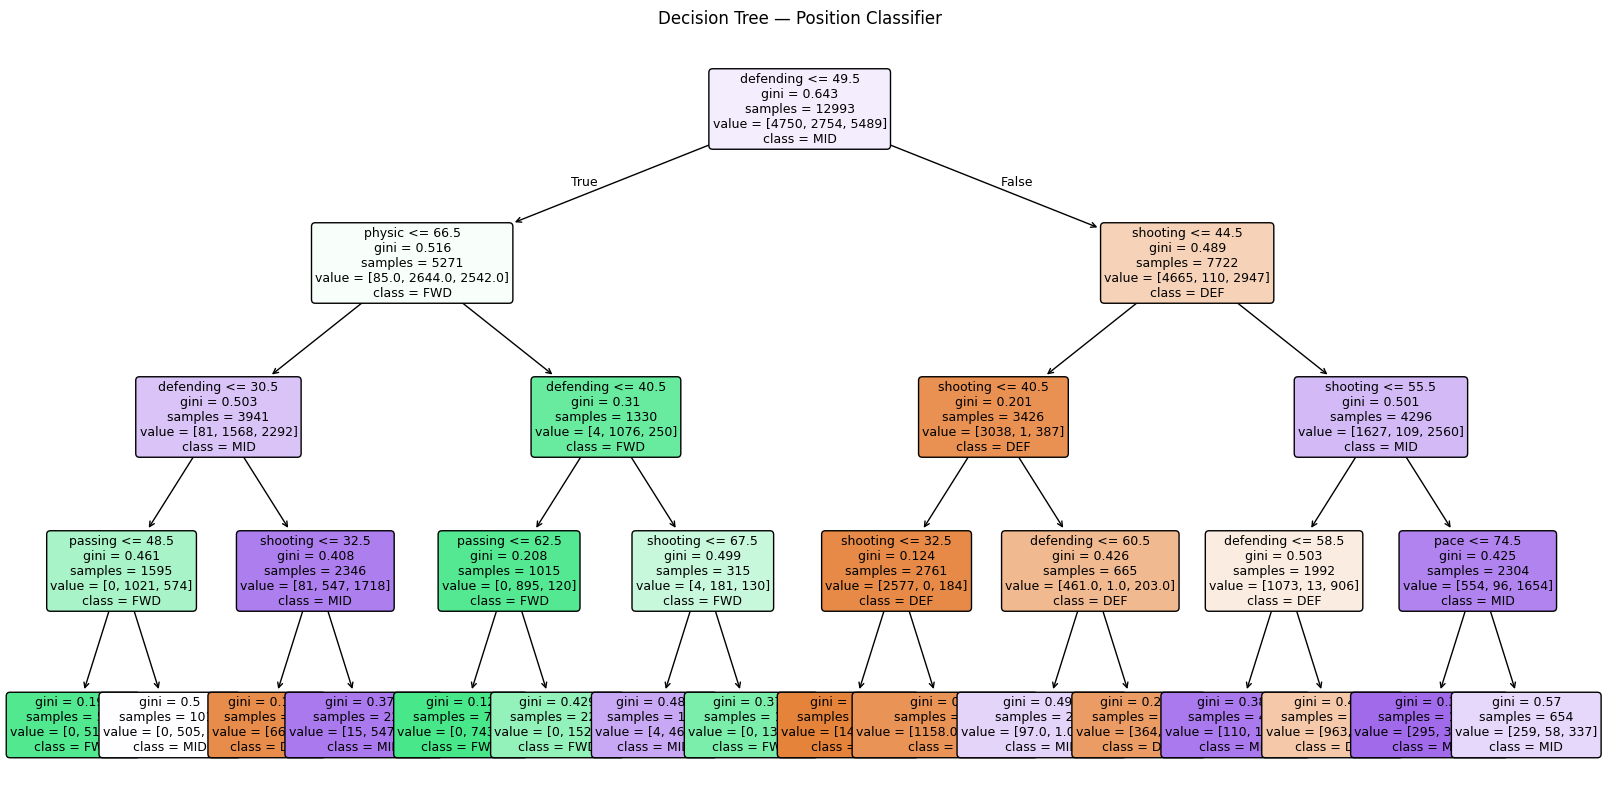

In [22]:
plt.figure(figsize=(20,10))
plot_tree(dtree,
          feature_names=features,
          class_names=dtree.classes_,
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Decision Tree — Position Classifier')
plt.show()

In [23]:
y_pred_tree = dtree.predict(X_test)

print("First 10 predictions:", y_pred_tree[:10])
print("First 10 real values:", y_test.values[:10])

First 10 predictions: ['DEF' 'DEF' 'MID' 'MID' 'FWD' 'DEF' 'DEF' 'MID' 'FWD' 'DEF']
First 10 real values: ['DEF' 'DEF' 'FWD' 'FWD' 'FWD' 'DEF' 'DEF' 'MID' 'FWD' 'DEF']


### **Decision Tree Results**

In [24]:
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy: {acc_tree:.3f}")
print()
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.743

              precision    recall  f1-score   support

         DEF       0.80      0.84      0.82      1188
         FWD       0.85      0.51      0.64       688
         MID       0.67      0.77      0.72      1373

    accuracy                           0.74      3249
   macro avg       0.77      0.71      0.73      3249
weighted avg       0.76      0.74      0.74      3249



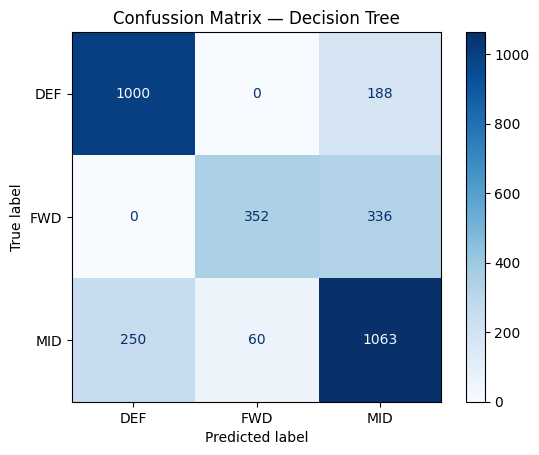

In [31]:
cm = confusion_matrix(y_test, y_pred_tree, labels=dtree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Blues')
plt.title('Confussion Matrix — Decision Tree')
plt.show()

The model is very accurate when it says “he's a forward” (85%), but it has trouble detecting all actual forwards (it only identifies 51%), it confuses them with attacking midfielders.

### **Random Forest model**

In [26]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, random_state=42)

In [28]:
y_pred_rf = rf.predict(X_test)

In [29]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf:.3f}")
print()
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.821

              precision    recall  f1-score   support

         DEF       0.84      0.89      0.86      1188
         FWD       0.89      0.72      0.80       688
         MID       0.78      0.81      0.79      1373

    accuracy                           0.82      3249
   macro avg       0.84      0.81      0.82      3249
weighted avg       0.82      0.82      0.82      3249



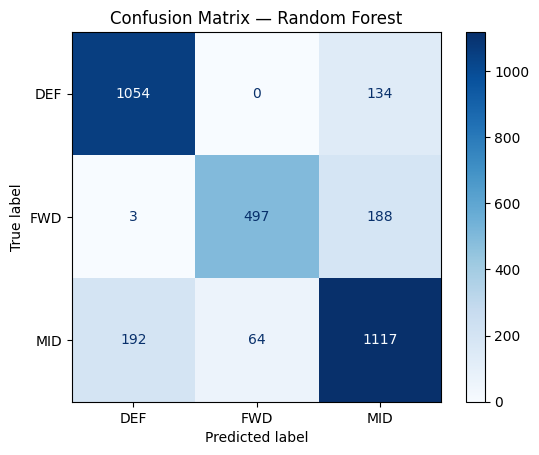

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf.classes_)
disp_rf.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()

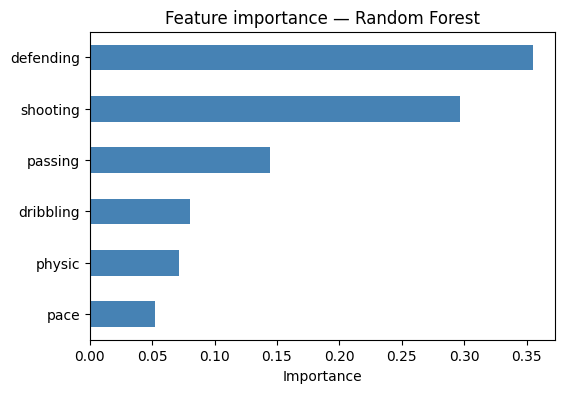

defending    0.354758
shooting     0.296658
passing      0.144718
dribbling    0.080638
physic       0.071322
pace         0.051906
dtype: float64


In [33]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature importance — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

print(importances)

## **Conclusions**


1. It is possible to predict a soccer player's position
  (DEF/MID/FWD) based on their in-game attributes in FIFA,
  with 82.1% accuracy using Random Forest.
2. Defense and shooting are the attributes that most distinguish
the positions
3. By combining 100 trees and averaging their scores, it reduces
overfitting and better captures ambiguous cases, especially
forwards with an attacking midfielder profile.
4. The biggest source of error is confusing FWD with MID (27%
of forwards are predicted to be midfielders), which
makes sense from a soccer perspective: the “false 9” and
“attacking midfielder” profiles are statistically hybrid positions.
